In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                             classification_report, roc_auc_score,
                             roc_curve)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/churn_data.csv')

print("✅ Dataset loaded!")
print(f"📊 Rows: {df.shape[0]}")
print(f"📋 Columns: {df.shape[1]}")
print(f"\n🔍 Column Names:")
print(df.columns.tolist())

✅ Dataset loaded!
📊 Rows: 7043
📋 Columns: 21

🔍 Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
# First look
print("📌 First 5 rows:")
df.head()

📌 First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check data types and missing values
print("📌 Data Info:")
print("="*50)
for col in df.columns:
    missing = df[col].isnull().sum()
    dtype = df[col].dtype
    print(f"{col:<20} | Type: {str(dtype):<10} | Missing: {missing}")

print("="*50)
print(f"\n📊 Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\n📊 Churn Percentage:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

📌 Data Info:
customerID           | Type: object     | Missing: 0
gender               | Type: object     | Missing: 0
SeniorCitizen        | Type: int64      | Missing: 0
Partner              | Type: object     | Missing: 0
Dependents           | Type: object     | Missing: 0
tenure               | Type: int64      | Missing: 0
PhoneService         | Type: object     | Missing: 0
MultipleLines        | Type: object     | Missing: 0
InternetService      | Type: object     | Missing: 0
OnlineSecurity       | Type: object     | Missing: 0
OnlineBackup         | Type: object     | Missing: 0
DeviceProtection     | Type: object     | Missing: 0
TechSupport          | Type: object     | Missing: 0
StreamingTV          | Type: object     | Missing: 0
StreamingMovies      | Type: object     | Missing: 0
Contract             | Type: object     | Missing: 0
PaperlessBilling     | Type: object     | Missing: 0
PaymentMethod        | Type: object     | Missing: 0
MonthlyCharges       | Type: floa

In [5]:
# DATA CLEANING
print("🧹 Cleaning data...")

# Step 1: Fix TotalCharges - convert to numeric
# Some values are empty spaces - replace with 0 first
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
print("✅ TotalCharges converted to numeric")

# Step 2: Drop customerID - not useful for prediction
df = df.drop('customerID', axis=1)
print("✅ customerID dropped")

# Step 3: Convert Churn to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Churn converted to binary (Yes=1, No=0)")

# Step 4: Convert all Yes/No columns to binary
binary_cols = ['Partner', 'Dependents', 'PhoneService', 
               'PaperlessBilling', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 
               'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 
                           'No phone service': 0, 
                           'No internet service': 0})
print("✅ Binary columns converted")

# Step 5: Encode categorical columns
le = LabelEncoder()
cat_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print("✅ Categorical columns encoded")

print(f"\n🎯 Final shape: {df.shape}")
print(f"✅ Data is clean and ready for ML!")

🧹 Cleaning data...
✅ TotalCharges converted to numeric
✅ customerID dropped
✅ Churn converted to binary (Yes=1, No=0)
✅ Binary columns converted
✅ Categorical columns encoded

🎯 Final shape: (7043, 20)
✅ Data is clean and ready for ML!


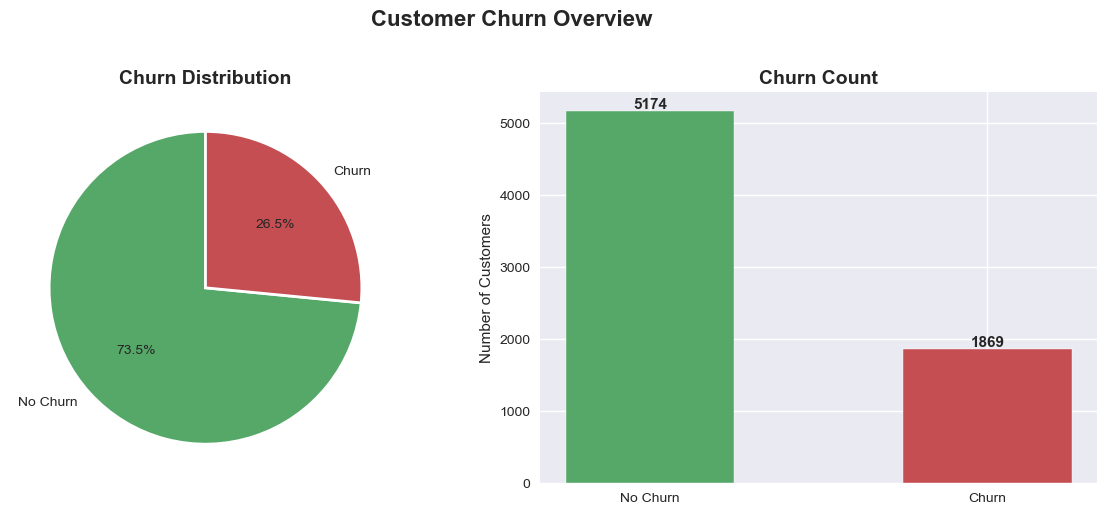

✅ Chart saved!


In [6]:
# CHART 1: Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts.values,
            labels=['No Churn', 'Churn'],
            autopct='%1.1f%%',
            colors=['#55A868', '#C44E52'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[1].bar(['No Churn', 'Churn'],
                    churn_counts.values,
                    color=['#55A868', '#C44E52'],
                    edgecolor='white',
                    width=0.5)

for bar, value in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 str(value),
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')

plt.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

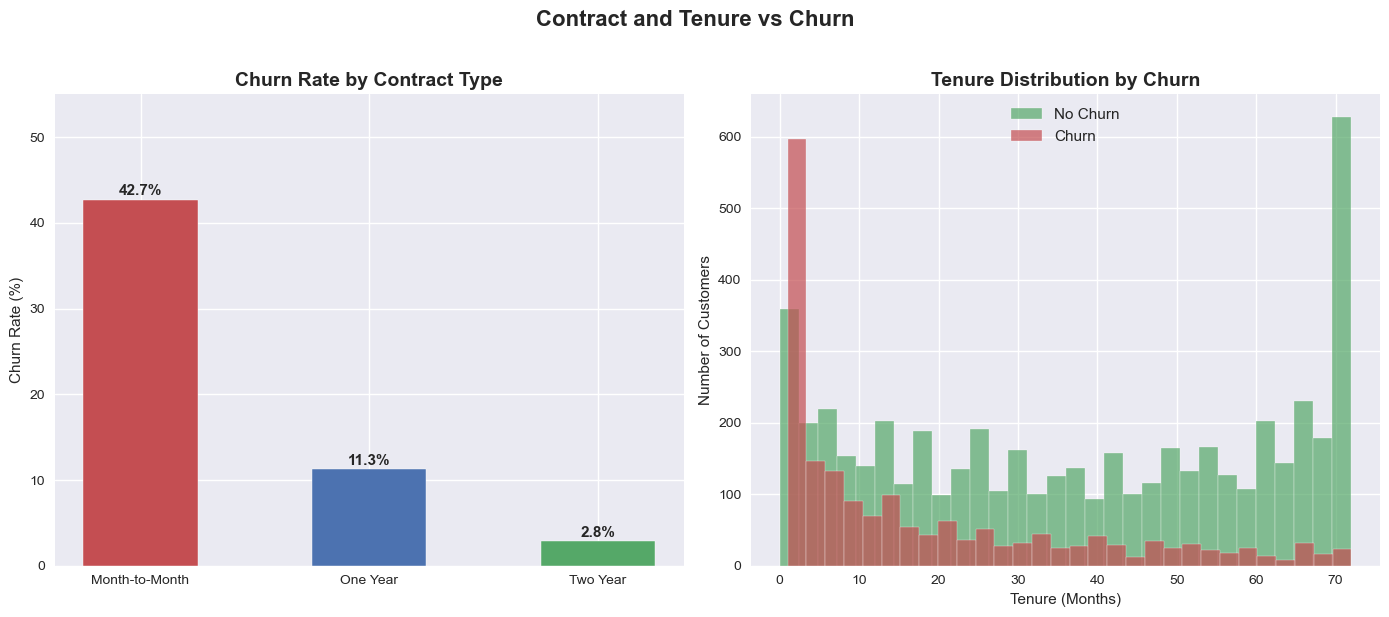

✅ Chart saved!


In [7]:
# CHART 2: Churn by Contract Type and Tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_labels = ['Month-to-Month', 'One Year', 'Two Year']
colors = ['#C44E52', '#4C72B0', '#55A868']

bars = axes[0].bar(contract_labels,
                   contract_churn.values,
                   color=colors,
                   edgecolor='white',
                   width=0.5)

for bar, value in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{value:.1f}%',
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

axes[0].set_title('Churn Rate by Contract Type',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 55)

# Tenure vs Churn
axes[1].hist(df[df['Churn']==0]['tenure'],
             bins=30, alpha=0.7,
             color='#55A868',
             label='No Churn',
             edgecolor='white')
axes[1].hist(df[df['Churn']==1]['tenure'],
             bins=30, alpha=0.7,
             color='#C44E52',
             label='Churn',
             edgecolor='white')

axes[1].set_title('Tenure Distribution by Churn',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Number of Customers')
axes[1].legend(fontsize=11)

plt.suptitle('Contract and Tenure vs Churn',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_contract_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

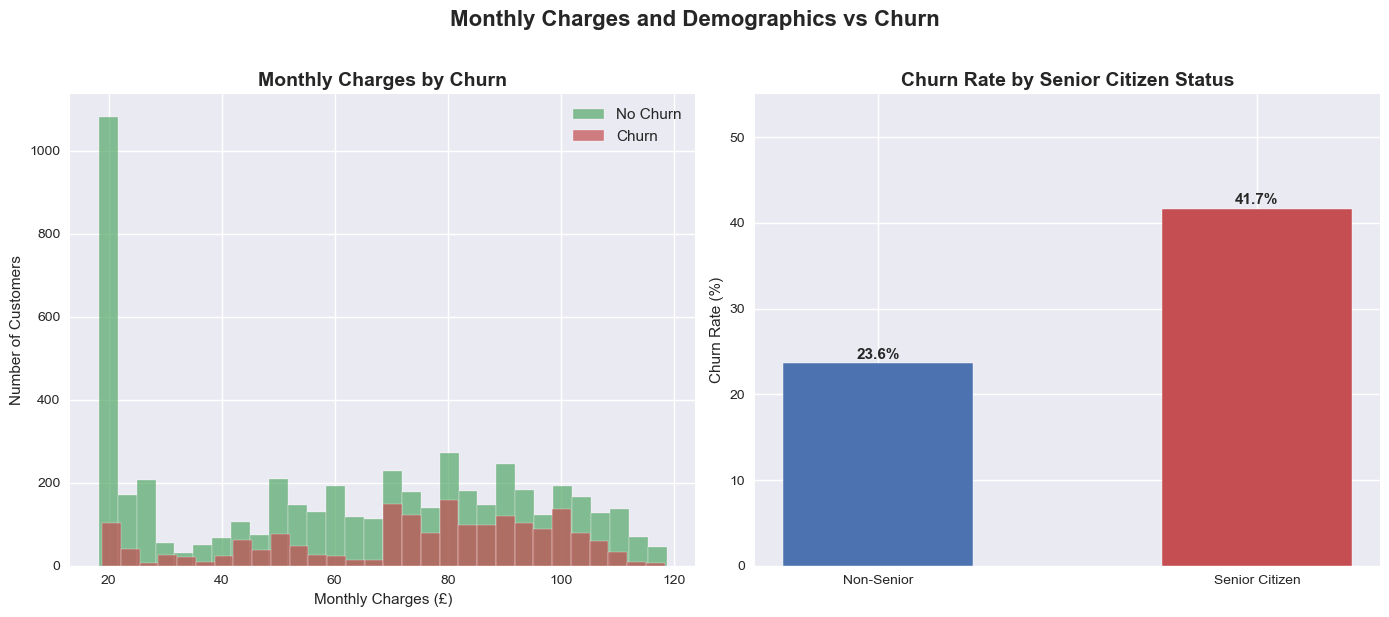

✅ Chart saved!


In [8]:
# CHART 3: Monthly Charges and Senior Citizen vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Monthly charges distribution by churn
axes[0].hist(df[df['Churn']==0]['MonthlyCharges'],
             bins=30, alpha=0.7,
             color='#55A868',
             label='No Churn',
             edgecolor='white')
axes[0].hist(df[df['Churn']==1]['MonthlyCharges'],
             bins=30, alpha=0.7,
             color='#C44E52',
             label='Churn',
             edgecolor='white')

axes[0].set_title('Monthly Charges by Churn',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Charges (£)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=11)

# Senior citizen churn rate
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
bars = axes[1].bar(['Non-Senior', 'Senior Citizen'],
                   senior_churn.values,
                   color=['#4C72B0', '#C44E52'],
                   edgecolor='white',
                   width=0.5)

for bar, value in zip(bars, senior_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{value:.1f}%',
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

axes[1].set_title('Churn Rate by Senior Citizen Status',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)

plt.suptitle('Monthly Charges and Demographics vs Churn',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_charges_senior_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [9]:
# MACHINE LEARNING - Train 3 models and compare them

# Step 1: Prepare features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Step 2: Split data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Data split complete!")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Testing samples:  {X_test.shape[0]}")

# Step 3: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"✅ Features scaled!")

# Step 4: Train all 3 models
print(f"\n🤖 Training models...")

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"✅ Logistic Regression trained! Accuracy: {lr_acc:.4f}")

# Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_acc = accuracy_score(y_test, dt_pred)
print(f"✅ Decision Tree trained!      Accuracy: {dt_acc:.4f}")

# Model 3: Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest trained!      Accuracy: {rf_acc:.4f}")

print(f"\n🏆 Best Model: ", end="")
best_acc = max(lr_acc, dt_acc, rf_acc)
if best_acc == rf_acc:
    print(f"Random Forest ({rf_acc:.4f})")
elif best_acc == lr_acc:
    print(f"Logistic Regression ({lr_acc:.4f})")
else:
    print(f"Decision Tree ({dt_acc:.4f})")

✅ Data split complete!
   Training samples: 5634
   Testing samples:  1409
✅ Features scaled!

🤖 Training models...
✅ Logistic Regression trained! Accuracy: 0.7999
✅ Decision Tree trained!      Accuracy: 0.7928
✅ Random Forest trained!      Accuracy: 0.7928

🏆 Best Model: Logistic Regression (0.7999)


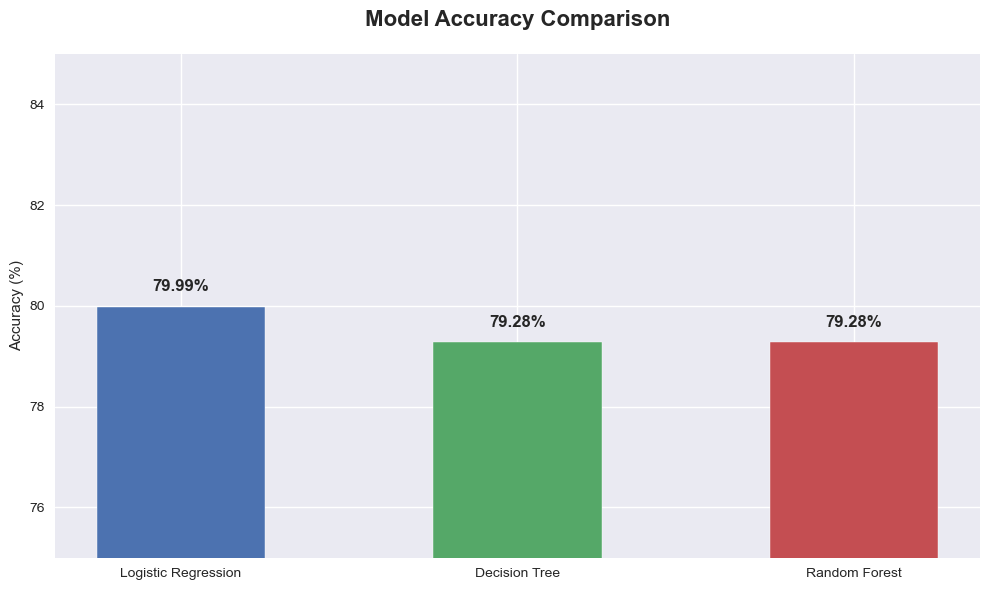

✅ Chart saved!


In [10]:
# CHART 4: Model Comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [lr_acc, dt_acc, rf_acc]
colors = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, 
               [acc * 100 for acc in accuracies],
               color=colors,
               edgecolor='white',
               width=0.5)

for bar, value in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{value*100:.2f}%',
             ha='center',
             fontsize=12,
             fontweight='bold')

plt.title('Model Accuracy Comparison',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Accuracy (%)')
plt.ylim(75, 85)
plt.tight_layout()
plt.savefig('../outputs/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

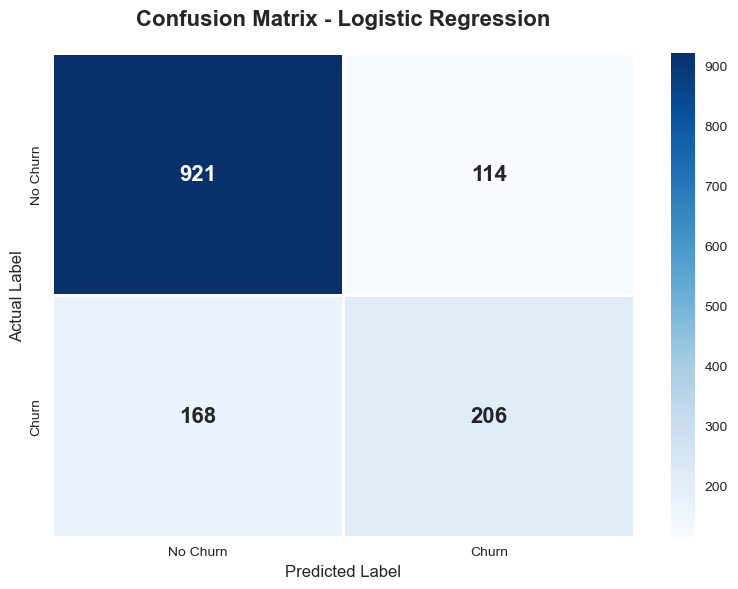

📊 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [11]:
# CHART 5: Confusion Matrix for best model (Logistic Regression)
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=2,
            linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})

plt.title('Confusion Matrix - Logistic Regression',
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print("📊 Classification Report:")
print("="*50)
print(classification_report(y_test, lr_pred, 
      target_names=['No Churn', 'Churn']))

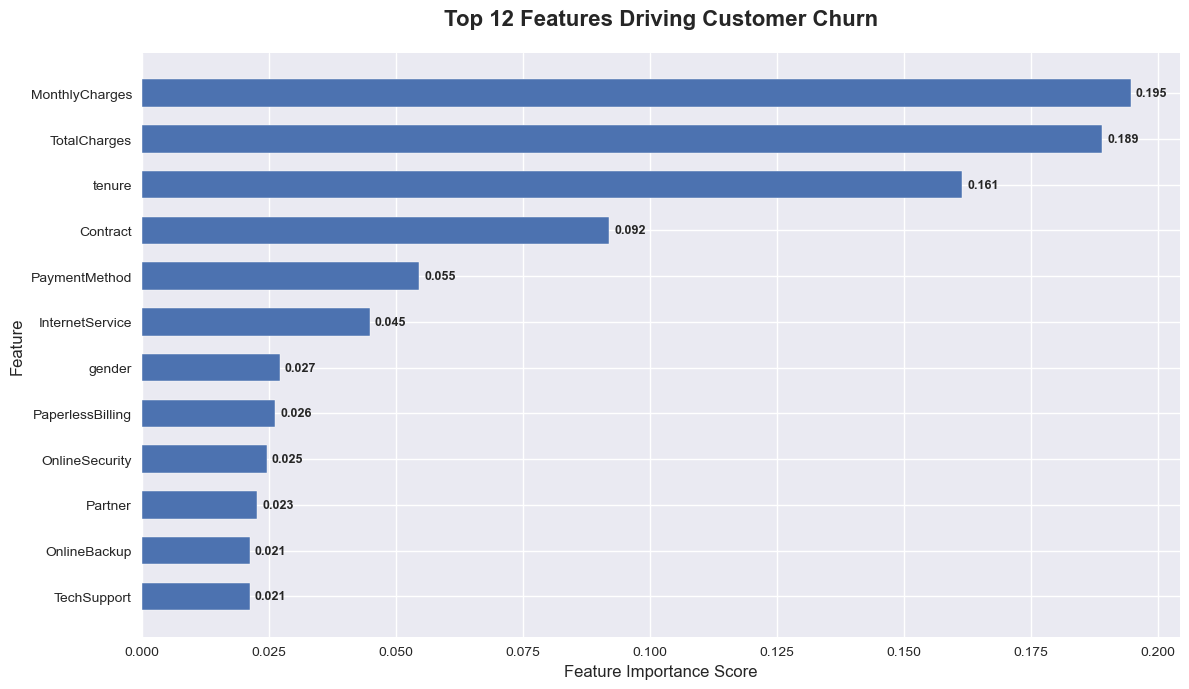

✅ Chart saved!


In [12]:
# CHART 6: Feature Importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(12, 7))
bars = plt.barh(feature_importance['Feature'],
                feature_importance['Importance'],
                color='#4C72B0',
                edgecolor='white',
                height=0.6)

for bar, value in zip(bars, feature_importance['Importance']):
    plt.text(value + 0.001,
             bar.get_y() + bar.get_height()/2,
             f'{value:.3f}',
             va='center',
             fontsize=9,
             fontweight='bold')

plt.title('Top 12 Features Driving Customer Churn',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")